# SBA 7(a) Loan Default Prediction (FY2020–Present)

This notebook implements a complete machine learning workflow to predict loan default using SBA 7(a) loan data (FY2020–present). The pipeline includes data preparation, supervised modeling, class-imbalance handling (SMOTE), model interpretation, and exploratory unsupervised clustering.

## 1. Imports and Global Configuration

All imports and global settings are centralized to keep the notebook readable, maintainable, and reproducible.

In [53]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Data

The dataset is loaded from a local CSV file. A quick sanity check is performed by printing the dataset shape and previewing the first rows.

In [16]:
DATA_PATH = Path("foia-7a-fy2020-present-asof-250930 (1).csv")  # update if needed

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file not found: {DATA_PATH.resolve()}\n"
        "Please place the file in the notebook directory or update DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (347514, 43)


,AsOfDate,Program,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,LocationID,BankName,BankFDICNumber,...,BusinessType,BusinessAge,LoanStatus,PaidinFullDate,ChargeoffDate,GrossChargeoffAmount,RevolverStatus,JobsSupported,CollateralInd,SoldSecondMarketInd
0,2025-09-30,7A,MID-KAM CRUSHING LLC,9000 Aetna Rd,Cleveland,OH,44105,57328.0,The Huntington National Bank,6560.0,...,CORPORATION,Existing or more than 2 years old,CANCLD,NaN,NaN,0.0,0,4.0,N,NaN
1,2025-09-30,7A,Yeadam,1428 CONTRA COSTA BLVD,PLEASANT HILL,CA,94523,433106.0,Poppy Bank,57903.0,...,CORPORATION,Existing or more than 2 years old,PIF,06/30/2023,NaN,0.0,0,12.0,Y,NaN
2,2025-09-30,7A,Dreadnought Brewing LLC,16726 146TH ST SE STE 153,MONROE,WA,98272,59698.0,Columbia Bank,17266.0,...,CORPORATION,Existing or more than 2 years old,EXEMPT,NaN,NaN,0.0,1,0.0,N,NaN
3,2025-09-30,7A,Big Oaks Golf Course LLC,3451 Big Oaks Golf Course,Saltillo,MS,38866,39848.0,Cadence Bank,11813.0,...,CORPORATION,"Startup, Loan Funds will Open Business",CANCLD,NaN,NaN,0.0,0,12.0,Y,NaN
4,2025-09-30,7A,Stillpoint Therapies LLC,"2469 Earl Campbell Parkway, Su",Tyler,TX,75701,70468.0,"Austin Bank, Texas National Association",3276.0,...,CORPORATION,"Startup, Loan Funds will Open Business",EXEMPT,NaN,NaN,0.0,0,5.0,Y,NaN


## 3. Target Definition

A binary target `LoanDefault` is defined using unambiguous loan outcomes:
- `CHGOFF` (charged off) → default (`1`)
- `PIF` (paid in full) → non-default (`0`)

To reduce label ambiguity, supervised modeling is restricted to these two statuses. The resulting target distribution is inspected to quantify class imbalance.

In [20]:
# Standardize status values to avoid issues with casing/whitespace
df_raw["LoanStatus"] = df_raw["LoanStatus"].astype(str).str.strip().str.upper()

# Keep only clear outcomes for supervised learning
df_model = df_raw[df_raw["LoanStatus"].isin(["PIF", "CHGOFF"])].copy()

# Binary target: 1=default, 0=non-default
df_model["LoanDefault"] = (df_model["LoanStatus"] == "CHGOFF").astype(int)

# Sanity checks and class distribution
counts = df_model["LoanDefault"].value_counts().sort_index()
props = df_model["LoanDefault"].value_counts(normalize=True).sort_index()

print("Modeling subset shape:", df_model.shape)
print("\nClass counts:\n", counts.rename({0: "non-default (0)", 1: "default (1)"}))
print("\nClass proportions:\n", props.rename({0: "non-default (0)", 1: "default (1)"}))

assert set(df_model["LoanDefault"].unique()) == {0, 1}, "Unexpected target values detected."


Modeling subset shape: (55954, 44)

Class counts:
 LoanDefault
non-default (0)    51791
default (1)         4163
Name: count, dtype: int64

Class proportions:
 LoanDefault
non-default (0)    0.9256
default (1)        0.0744
Name: proportion, dtype: float64


The target is imbalanced: defaults represent ~7.4% of the modeling subset. This motivates the use of imbalance-aware evaluation (e.g., ROC-AUC/PR-AUC) and class-balancing techniques such as SMOTE later in the workflow.

## 4. Data Cleaning for Modeling

To prepare the dataset for supervised modeling, text-heavy identifiers and leakage-prone fields are removed.
In particular, any columns that reflect the final outcome (e.g., payoff/charge-off dates and amounts, or the original status label used to define the target) are excluded to prevent target leakage.

A compact industry-sector feature (`NAICS2`) is engineered from `NAICSCode` by keeping the 2-digit prefix (sector level).
Missing values are intentionally handled later inside the preprocessing pipelines (imputation + encoding + scaling) to avoid leakage across train/test splits.

In [34]:
cols_to_drop = [
    "BorrName","BorrStreet","BorrCity",
    "BankName","BankStreet","BankCity",
    "FranchiseName","FranchiseCode",
    "PaidinFullDate","ChargeoffDate","GrossChargeoffAmount",
    "BankNCUANumber",
    "LoanStatus",        # leakage source (used to define the target)
    "NAICSDescription"   # high-cardinality text; NAICS2 keeps the signal
]

df_model_clean = df_model.drop(columns=cols_to_drop, errors="ignore").reset_index(drop=True)

# NAICS: keep a 2-digit sector code as categorical signal (sector-level)
df_model_clean["NAICS2"] = df_model_clean["NAICSCode"].astype(str).str.zfill(6).str[:2]

df_model_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55954 entries, 0 to 55953
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   AsOfDate                     55954 non-null  object 
 1   Program                      55954 non-null  object 
 2   BorrState                    55954 non-null  object 
 3   BorrZip                      55954 non-null  int64  
 4   LocationID                   55834 non-null  float64
 5   BankFDICNumber               50850 non-null  float64
 6   BankState                    55834 non-null  object 
 7   BankZip                      55834 non-null  float64
 8   GrossApproval                55954 non-null  float64
 9   SBAGuaranteedApproval        55954 non-null  float64
 10  ApprovalDate                 55954 non-null  object 
 11  ApprovalFY                   55954 non-null  int64  
 12  FirstDisbursementDate        55951 non-null  object 
 13  ProcessingMethod

The cleaned dataset retains structured loan attributes while removing identifiers and post-outcome fields. The resulting table is ready for feature selection, stratified splitting, and pipeline-based preprocessing.

## 5. Feature Set and Train/Test Split

A modeling feature set is defined using variables that are available at (or near) loan approval time to reduce information leakage.
Features are grouped into numeric and categorical types to support pipeline-based preprocessing.

A stratified train/test split is applied to preserve the default ratio in both subsets, enabling fair evaluation under class imbalance.

In [38]:
TARGET_COL = "LoanDefault"

# Ensure binary indicators are treated as categorical when one-hot encoded
df_model_clean["RevolverStatus"] = df_model_clean["RevolverStatus"].astype(str)

numeric_features = [
    "GrossApproval",
    "SBAGuaranteedApproval",
    "InitialInterestRate",
    "TerminMonths",
    "JobsSupported",
    "ApprovalFY"
]

categorical_features = [
    "Program",
    "BorrState",
    "ProjectState",
    "BusinessType",
    "BusinessAge",
    "ProcessingMethod",
    "Subprogram",
    "FixedorVariableInterestRate",
    "CollateralInd",
    "RevolverStatus",
    "NAICS2"
]

X = df_model_clean[numeric_features + categorical_features].copy()
y = df_model_clean[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

# Verify stratification (class balance preserved)
train_rate = y_train.mean()
test_rate = y_test.mean()
print(f"Default rate (train): {train_rate:.4f}")
print(f"Default rate (test) : {test_rate:.4f}")

Train: (44763, 17)  Test: (11191, 17)
Default rate (train): 0.0744
Default rate (test) : 0.0744


The default rates in the train and test sets are nearly identical, confirming that stratification preserved the original class distribution for evaluation.

## 6. Preprocessing Pipeline

A reusable preprocessing pipeline is defined for all supervised models:
- Numeric features: missing values are imputed (median) and then scaled.
- Categorical features: missing values are imputed (most frequent) and then one-hot encoded.

Handling missing values inside the pipeline ensures that imputation is learned only from the training data in each split, reducing the risk of data leakage.

In [43]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['GrossApproval', 'SBAGuaranteedApproval',
                                  'InitialInterestRate', 'TerminMonths',
                                  'JobsSupported', 'ApprovalFY']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Program', 'BorrState', 'ProjectState',
                                  'BusinessType', 'BusinessAge',
                                  'ProcessingMethod', 'Subprogram',
                                  'FixedorVariableInterestRate',
                                  'CollateralInd', 'RevolverStatus',
                                  'NAICS2'])])

## 7. EDA (Two Plots)

Two exploratory checks are performed:
1) Default rate by approval year (`ApprovalFY`)
2) Default rate by industry sector (`NAICS2`, 2-digit)

These plots provide an initial view of temporal patterns and sector-level risk differences before model training.

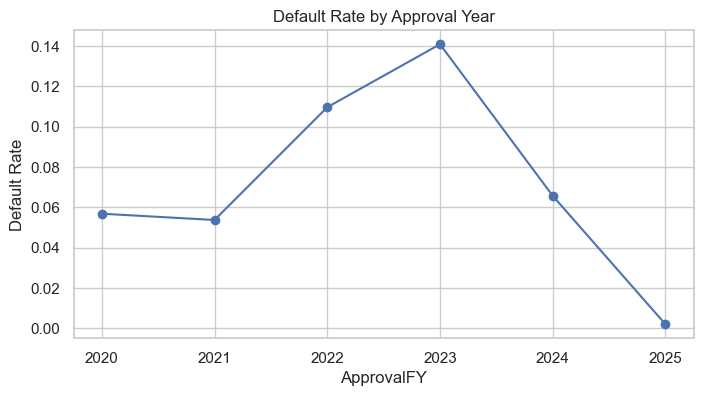

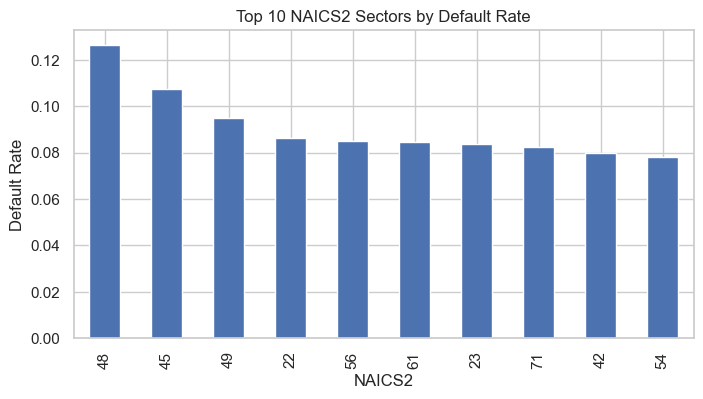

In [46]:
# 7.1 Default rate by approval year
default_by_year = df_model_clean.groupby("ApprovalFY")["LoanDefault"].mean().sort_index()

plt.figure(figsize=(8, 4))
default_by_year.plot(marker="o")
plt.title("Default Rate by Approval Year")
plt.xlabel("ApprovalFY")
plt.ylabel("Default Rate")
plt.grid(True)
plt.show()

# 7.2 Default rate by NAICS2 sector (top 10)
df_naics = df_model_clean.copy()
df_naics["NAICS2"] = df_naics["NAICS2"].astype(str).str.strip()

default_by_naics = (
    df_naics[df_naics["NAICS2"].str.match(r"^\d{2}$", na=False)]
    .groupby("NAICS2")["LoanDefault"].mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
default_by_naics.plot(kind="bar")
plt.title("Top 10 NAICS2 Sectors by Default Rate")
plt.xlabel("NAICS2")
plt.ylabel("Default Rate")
plt.grid(True, axis="y")
plt.show()

The exploratory analysis highlights two useful patterns.

First, default rates vary across approval years, suggesting that temporal and macroeconomic conditions may influence portfolio risk. The most recent approval year(s) should be interpreted cautiously due to right-censoring: recently approved loans have had less time to reach a charge-off outcome, and the supervised subset includes only finalized outcomes (PIF/CHGOFF).

Second, default rates differ substantially across industry sectors (`NAICS2`), indicating that sector-level business activity is an important risk signal.

These observations support the inclusion of both temporal features and industry-based categorical variables in the supervised modeling stage.

## 8. Evaluation Utilities

A unified evaluation function is used to ensure consistent reporting across models.
Because the dataset is imbalanced, multiple complementary metrics are reported (precision, recall, F1, ROC-AUC, and PR-AUC when probabilities are available).

In [55]:
def evaluate_classifier(name, y_true, y_pred, y_proba=None, verbose=True):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    out = {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": None,
        "pr_auc": None
    }

    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
        out["pr_auc"] = average_precision_score(y_true, y_proba)

    if verbose:
        print(f"=== {name} ===")
        print(f"Accuracy : {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall   : {rec:.3f}")
        print(f"F1-score : {f1:.3f}")

        if y_proba is not None:
            print(f"ROC-AUC  : {out['roc_auc']:.3f}")
            print(f"PR-AUC   : {out['pr_auc']:.3f}")

        print("\nClassification report:")
        print(classification_report(y_true, y_pred, zero_division=0))

    return out

results = []

## 9. Logistic Regression

Logistic Regression is used as a strong linear baseline classifier. To mitigate the strong class imbalance, `class_weight="balanced"` is applied so that misclassifying defaulted loans (the minority class) receives a higher penalty.

Hyperparameter tuning is performed over the regularization strength (`C`) using cross-validation. The model is selected using F1-score to balance precision and recall for the default class.

In [67]:
log_clf = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

log_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", log_clf)
])

grid_log = GridSearchCV(
    log_pipe,
    param_grid={"clf__C": [0.01, 0.1, 1.0, 10.0]},
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_log.fit(X_train, y_train)

print("Best parameters:", grid_log.best_params_)
print(f"Best CV F1: {grid_log.best_score_:.3f}")

y_pred = grid_log.predict(X_test)
y_proba = grid_log.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Logistic Regression", y_test, y_pred, y_proba))

Best parameters: {'clf__C': 10.0}
Best CV F1: 0.378
=== Logistic Regression ===
Accuracy : 0.798
Precision: 0.246
Recall   : 0.833
F1-score : 0.380
ROC-AUC  : 0.878
PR-AUC   : 0.352

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     10358
           1       0.25      0.83      0.38       833

    accuracy                           0.80     11191
   macro avg       0.61      0.81      0.63     11191
weighted avg       0.93      0.80      0.84     11191



***Logistic Regression – Results***

The tuned Logistic Regression model selected `C = 10.0` (best CV F1 ≈ 0.378). On the test set, the model achieved high sensitivity to defaults (Recall = 0.833), meaning that most defaulted loans were correctly identified. However, precision was low (Precision = 0.246), indicating a substantial number of false positives where non-default loans were flagged as defaults.

This trade-off is expected under strong class imbalance, especially with `class_weight="balanced"`, which emphasizes reducing missed defaults (false negatives). Ranking performance was strong (ROC-AUC = 0.878), while PR-AUC was more modest (PR-AUC = 0.352), providing a conservative summary focused on the minority default class.

Overall, Logistic Regression serves as a strong baseline and an effective risk-screening model, but its low precision suggests that threshold tuning, calibration, or a second-stage review/model may be needed to reduce false alerts in operational settings.

## 10. K-Nearest Neighbors (KNN)

KNN is a distance-based classifier that predicts the label of an observation using the majority vote (or distance-weighted vote) of its nearest neighbors in feature space. In strongly imbalanced datasets, neighbor composition is often dominated by the majority class, which can reduce sensitivity to the minority default class.

A small hyperparameter search is performed over the number of neighbors and the voting scheme. The model is selected using cross-validated F1-score to balance precision and recall for default prediction.

In [71]:
knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", KNeighborsClassifier())
])

grid_knn = GridSearchCV(
    knn_pipe,
    param_grid={
        "clf__n_neighbors": [3, 5, 7, 9],
        "clf__weights": ["uniform", "distance"]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_knn.fit(X_train, y_train)

print("Best parameters:", grid_knn.best_params_)
print(f"Best CV F1: {grid_knn.best_score_:.3f}")

y_pred = grid_knn.predict(X_test)
y_proba = grid_knn.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("KNN", y_test, y_pred, y_proba))

Best parameters: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Best CV F1: 0.296
=== KNN ===
Accuracy : 0.921
Precision: 0.441
Recall   : 0.235
F1-score : 0.307
ROC-AUC  : 0.700
PR-AUC   : 0.260

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     10358
           1       0.44      0.24      0.31       833

    accuracy                           0.92     11191
   macro avg       0.69      0.61      0.63     11191
weighted avg       0.90      0.92      0.91     11191



***K-Nearest Neighbors (KNN) – Results***

The tuned KNN model selected `n_neighbors = 3` with `weights = distance` (best CV F1 ≈ 0.296). On the test set, the model achieved high overall accuracy (Accuracy = 0.921), but this metric is misleading under strong class imbalance. Performance on the default class was weak (Recall = 0.235, F1 = 0.307), indicating that many defaults were missed.

Although precision for predicted defaults was moderate (Precision = 0.441), the low recall and modest minority-class ranking performance (PR-AUC = 0.260) suggest that KNN strongly favors the majority class. This behavior is consistent with distance-based methods in imbalanced settings, where local neighborhoods are dominated by non-default observations.

Overall, KNN is not a competitive choice for risk-sensitive default screening compared with approaches that explicitly address imbalance (e.g., class weighting, resampling, or tree-based ensembles).

Next, tree-based models are evaluated, as they can capture non-linear relationships and interactions that are not modeled by linear classifiers and may improve minority-class performance.

## 11. Random Forest

Random Forest is an ensemble of decision trees that improves stability and captures non-linear relationships and feature interactions. To reduce bias toward the majority class under class imbalance, `class_weight="balanced"` is applied.

Hyperparameter tuning is performed over the number of trees, maximum depth, and the minimum samples required to split a node. The model is selected using cross-validated F1-score to balance precision and recall for the default class.

In [79]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=2
    ))
])

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid={
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print(f"Best CV F1: {grid_rf.best_score_:.3f}")

y_pred = grid_rf.predict(X_test)
y_proba = grid_rf.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Random Forest", y_test, y_pred, y_proba))

Best parameters: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1: 0.726
=== Random Forest ===
Accuracy : 0.965
Precision: 0.860
Recall   : 0.634
F1-score : 0.730
ROC-AUC  : 0.969
PR-AUC   : 0.825

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10358
           1       0.86      0.63      0.73       833

    accuracy                           0.97     11191
   macro avg       0.92      0.81      0.86     11191
weighted avg       0.96      0.97      0.96     11191



***Random Forest – Results***

The tuned Random Forest model selected `n_estimators = 200`, `max_depth = None`, and `min_samples_split = 5` (best CV F1 ≈ 0.726). On the test set, the model achieved strong performance with very high precision (Precision = 0.860) and a solid balance between precision and recall (F1 = 0.730). Discrimination and minority-class ranking were excellent (ROC-AUC = 0.969, PR-AUC = 0.825).

Recall for defaults was moderate (Recall = 0.634), indicating that a meaningful portion of default cases was detected, while some defaults were still missed. Compared with Logistic Regression, this reflects a more conservative operating behavior: fewer false positives (higher precision) at the cost of more false negatives (lower recall).

Overall, Random Forest provides a strong and practical model for default prediction, offering robust non-linear modeling and excellent ranking ability. If maximizing default detection is the primary objective, threshold tuning and/or resampling (e.g., SMOTE) can be explored to increase recall at the cost of additional false positives.

## 12. Gradient Boosting (Baseline)

Gradient Boosting is a powerful ensemble method that builds trees sequentially, where each new tree corrects errors made by the previous ones. This model is evaluated without resampling to provide a baseline comparison before introducing SMOTE.

Hyperparameter tuning is performed over the number of estimators, learning rate, and tree depth. The model is selected using cross-validated F1-score to balance precision and recall for the default class.

In [86]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

grid_gb = GridSearchCV(
    gb_pipe,
    param_grid={
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [3, 5]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_gb.fit(X_train, y_train)

print("Best parameters:", grid_gb.best_params_)
print(f"Best CV F1: {grid_gb.best_score_:.3f}")

y_pred = grid_gb.predict(X_test)
y_proba = grid_gb.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Gradient Boosting (Baseline)", y_test, y_pred, y_proba))

Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV F1: 0.832
=== Gradient Boosting (Baseline) ===
Accuracy : 0.976
Precision: 0.868
Recall   : 0.801
F1-score : 0.833
ROC-AUC  : 0.979
PR-AUC   : 0.873

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     10358
           1       0.87      0.80      0.83       833

    accuracy                           0.98     11191
   macro avg       0.93      0.90      0.91     11191
weighted avg       0.98      0.98      0.98     11191



***Gradient Boosting (Baseline) – Results***

The tuned Gradient Boosting baseline selected `n_estimators = 200`, `learning_rate = 0.1`, and `max_depth = 5` (best CV F1 ≈ 0.832). On the test set, the model achieved an excellent balance between identifying defaults and limiting false alarms, with high precision and recall for the default class (Precision = 0.868, Recall = 0.801), resulting in a strong F1-score (F1 = 0.833).

Discrimination and minority-class ranking performance were outstanding (ROC-AUC = 0.979, PR-AUC = 0.873), indicating strong separation between default and non-default loans and robust performance under class imbalance.

Overall, Gradient Boosting provides the strongest baseline performance so far and is a leading candidate for final selection. In the next stage, SMOTE-based resampling can be evaluated to test whether default recall can be increased further without an unacceptable increase in false positives.

## 13. Decision Tree

A Decision Tree is an interpretable model that learns a set of hierarchical if–then rules. While trees can capture non-linear relationships, they are more prone to overfitting compared with ensemble methods.

To mitigate the strong class imbalance, `class_weight="balanced"` is applied. Hyperparameter tuning is performed over tree depth and the minimum samples required to split a node. The model is selected using cross-validated F1-score to balance precision and recall for the default class.

In [94]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

grid_dt = GridSearchCV(
    dt_pipe,
    param_grid={
        "clf__max_depth": [5, 10, 20, None],
        "clf__min_samples_split": [2, 5, 10]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_dt.fit(X_train, y_train)

print("Best parameters:", grid_dt.best_params_)
print(f"Best CV F1: {grid_dt.best_score_:.3f}")

y_pred = grid_dt.predict(X_test)
y_proba = grid_dt.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier("Decision Tree", y_test, y_pred, y_proba))

Best parameters: {'clf__max_depth': 20, 'clf__min_samples_split': 2}
Best CV F1: 0.742
=== Decision Tree ===
Accuracy : 0.959
Precision: 0.692
Recall   : 0.800
F1-score : 0.742
ROC-AUC  : 0.887
PR-AUC   : 0.592

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     10358
           1       0.69      0.80      0.74       833

    accuracy                           0.96     11191
   macro avg       0.84      0.89      0.86     11191
weighted avg       0.96      0.96      0.96     11191



***Decision Tree – Results***

The tuned Decision Tree selected `max_depth = 20` and `min_samples_split = 2` (best CV F1 ≈ 0.742). On the test set, the model achieved high sensitivity to defaults (Recall = 0.800), meaning that most default cases were correctly identified. Precision was moderate (Precision = 0.692), resulting in a solid overall balance (F1 = 0.742).

Ranking performance was moderate compared with the strongest ensemble models (ROC-AUC = 0.887, PR-AUC = 0.592), indicating that the tree separates the classes reasonably well but less consistently than Random Forest or Gradient Boosting.

Overall, the Decision Tree provides strong interpretability and competitive recall for default detection, but it is typically less stable and more prone to overfitting than ensemble approaches. As a result, it is useful for explanation and baseline comparison, while ensemble models remain preferable for robust predictive performance.

## 14. Supervised Model Comparison (Baseline)

Baseline supervised models are compared using metrics that are appropriate under class imbalance.
F1-score summarizes the precision–recall trade-off for the default class, while ROC-AUC and PR-AUC reflect ranking performance (with PR-AUC being especially informative for the minority class).

Models are ranked primarily by F1-score, and ROC-AUC / PR-AUC are used as complementary indicators of discrimination and minority-class ranking quality.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
5,Gradient Boosting (Baseline),0.976,0.868,0.801,0.833,0.979,0.873
6,Decision Tree,0.959,0.692,0.800,0.742,0.887,0.592
4,Random Forest,0.965,0.860,0.634,0.730,0.969,0.825
0,Logistic Regression,0.798,0.246,0.833,0.380,0.878,0.352
1,KNN,0.921,0.441,0.235,0.307,0.700,0.260


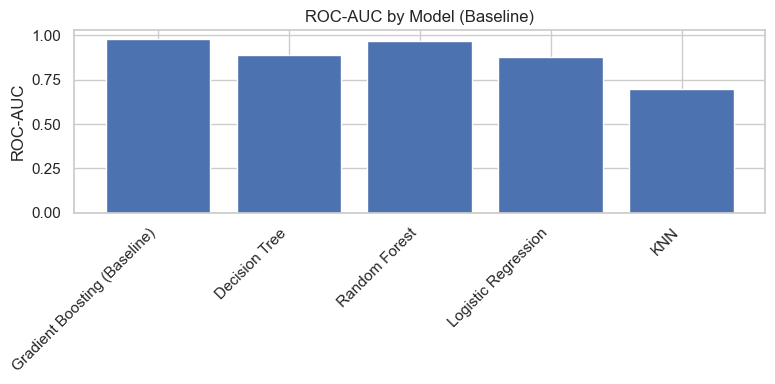

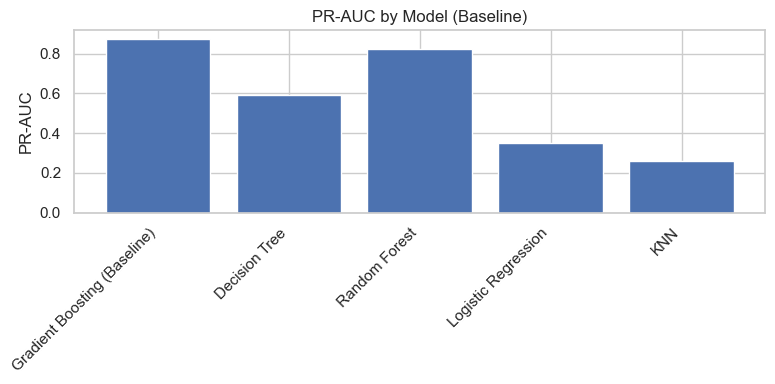

In [98]:
# Build comparison table
results_df = pd.DataFrame(results).drop_duplicates(subset="model").round(3)

# Sort by F1 (primary metric for imbalanced classification)
results_sorted = results_df.sort_values(by="f1", ascending=False)

display(results_sorted)

# Plot ROC-AUC by model (sorted by F1 for readability)
plt.figure(figsize=(8, 4))
plt.bar(results_sorted["model"], results_sorted["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.title("ROC-AUC by Model (Baseline)")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

# Plot PR-AUC by model (if available)
if "pr_auc" in results_sorted.columns and results_sorted["pr_auc"].notna().any():
    plt.figure(figsize=(8, 4))
    plt.bar(results_sorted["model"], results_sorted["pr_auc"])
    plt.xticks(rotation=45, ha="right")
    plt.title("PR-AUC by Model (Baseline)")
    plt.ylabel("PR-AUC")
    plt.tight_layout()
    plt.show()

***Model Comparison – Baseline Results***

The baseline comparison reveals clear performance differences under class imbalance. Gradient Boosting achieved the strongest overall results, with the highest F1-score (F1 = 0.833) and excellent ranking performance (ROC-AUC = 0.979, PR-AUC = 0.873). This indicates the best balance between capturing defaulted loans and limiting false alarms among the tested baselines.

Random Forest also performed strongly, with very high precision (Precision = 0.860) and excellent discrimination (ROC-AUC = 0.969, PR-AUC = 0.825), but it achieved lower recall (Recall = 0.634), reflecting a more conservative operating behavior that misses more defaults than Gradient Boosting. The Decision Tree provided competitive recall (Recall = 0.800) and a solid F1-score (F1 = 0.742), but its ranking metrics were substantially lower (ROC-AUC = 0.887, PR-AUC = 0.592), suggesting less stable separation between default and non-default cases compared to ensemble methods.

Logistic Regression and KNN were less effective overall. Logistic Regression prioritized recall (Recall = 0.833) at the cost of very low precision (Precision = 0.246), producing a low F1-score (F1 = 0.380). KNN showed the weakest default detection (Recall = 0.235, F1 = 0.307) and the lowest ranking performance (ROC-AUC = 0.700, PR-AUC = 0.260), indicating poor suitability for risk-sensitive default screening.

Based on these baseline results, Gradient Boosting is selected as the leading candidate for further improvement using imbalance-handling techniques (e.g., SMOTE) and potential threshold tuning to optimize the precision–recall trade-off.

## 15. Gradient Boosting + SMOTE (Imbalance Handling Experiment)

To explicitly address class imbalance, SMOTE is applied **inside an imblearn pipeline**.
This design ensures that oversampling is performed **only on the training folds** during cross-validation,
preventing information leakage into the test set and producing a more reliable evaluation.

In [157]:
gb_smote_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

grid_gb_smote = GridSearchCV(
    gb_smote_pipe,
    param_grid={
        "clf__n_estimators": [200],
        "clf__learning_rate": [0.1],
        "clf__max_depth": [5]
    },
    cv=3,
    scoring="f1",
    n_jobs=2
)

grid_gb_smote.fit(X_train, y_train)

print("Best parameters:", grid_gb_smote.best_params_)
print(f"Best CV F1: {grid_gb_smote.best_score_:.3f}")

# Save final-model predictions with explicit names (avoids confusion later)
y_pred_gb_smote  = grid_gb_smote.predict(X_test)
y_proba_gb_smote = grid_gb_smote.predict_proba(X_test)[:, 1]

results.append(
    evaluate_classifier("Gradient Boosting + SMOTE", y_test, y_pred_gb_smote, y_proba_gb_smote)
)

/Users/rebeccaelhaj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/rebeccaelhaj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/rebeccaelhaj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV F1: 0.822
=== Gradient Boosting + SMOTE ===
Accuracy : 0.973
Precision: 0.808
Recall   : 0.843
F1-score : 0.825
ROC-AUC  : 0.979
PR-AUC   : 0.878

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     10358
           1       0.81      0.84      0.82       833

    accuracy                           0.97     11191
   macro avg       0.90      0.91      0.91     11191
weighted avg       0.97      0.97      0.97     11191



***Gradient Boosting + SMOTE – Results***

The tuned Gradient Boosting + SMOTE model selected `n_estimators = 200`, `learning_rate = 0.1`, and `max_depth = 5` (best CV F1 ≈ 0.822). On the test set, the model achieved strong minority-class performance, with high recall for defaults (Recall = 0.843) and solid precision (Precision = 0.808), resulting in a strong overall balance (F1 = 0.825).

Discrimination and ranking performance remained excellent (ROC-AUC = 0.979, PR-AUC = 0.878), indicating robust separation between default and non-default loans under class imbalance. Relative to the baseline Gradient Boosting model, SMOTE shifted the operating point toward higher default detection (higher recall) at the cost of reduced precision, reflecting the expected precision–recall trade-off when oversampling the minority class.

Overall, Gradient Boosting + SMOTE provides a more recall-oriented model that is well-suited for risk-sensitive screening scenarios where missing defaults (false negatives) is costly. Final model choice should be guided by the business objective: prioritize this SMOTE variant when maximizing default detection is critical, or prefer the baseline model when higher precision and slightly higher F1 are preferred.

## 16. Final Comparison (Including SMOTE)

All supervised models are compared after adding the SMOTE experiment. The final selection is based on imbalance-aware performance: F1-score (precision–recall balance) alongside recall and PR-AUC, since detecting defaults (minority class) is the primary risk-sensitive objective.

In [110]:
final_results_df = pd.DataFrame(results).drop_duplicates(subset="model").round(3)

# Rank primarily by F1-score (with recall as a secondary lens for default detection)
final_sorted = final_results_df.sort_values(by="f1", ascending=False)
display(final_sorted)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
5,Gradient Boosting (Baseline),0.976,0.868,0.801,0.833,0.979,0.873
8,Gradient Boosting + SMOTE,0.973,0.808,0.843,0.825,0.979,0.878
6,Decision Tree,0.959,0.692,0.800,0.742,0.887,0.592
4,Random Forest,0.965,0.860,0.634,0.730,0.969,0.825
0,Logistic Regression,0.798,0.246,0.833,0.380,0.878,0.352
1,KNN,0.921,0.441,0.235,0.307,0.700,0.260


***Final Model Comparison and Selection***

The final comparison confirms that the two Gradient Boosting variants provide the strongest overall performance under class imbalance. The baseline Gradient Boosting model achieved the best F1-score (F1 = 0.833) with high precision and recall (Precision = 0.868, Recall = 0.801) and excellent ranking performance (ROC-AUC = 0.979, PR-AUC = 0.873).

The Gradient Boosting + SMOTE model produced a slightly lower F1-score (F1 = 0.825) due to reduced precision (Precision = 0.808), but it improved default detection with higher recall (Recall = 0.843) and achieved the highest PR-AUC (PR-AUC = 0.878), indicating stronger performance for ranking and retrieving minority-class defaults. This reflects the expected precision–recall trade-off when oversampling the minority class.

Random Forest and Decision Tree delivered solid results but were weaker than Gradient Boosting overall: Random Forest showed excellent precision and ranking (PR-AUC = 0.825) but lower recall (Recall = 0.634), while the Decision Tree achieved strong recall (Recall = 0.800) but substantially weaker ranking quality (PR-AUC = 0.592). Logistic Regression and KNN were the least effective in terms of F1 and minority-class ranking.

Final model choice depends on the operational objective. If the goal is to maximize balanced performance (highest F1 with strong precision), the baseline Gradient Boosting model is preferred. If the goal is risk-sensitive screening where missing defaults (false negatives) is more costly, the SMOTE-enhanced Gradient Boosting model is preferred due to its higher recall and best PR-AUC. Under the credit-risk screening perspective, Gradient Boosting + SMOTE is selected as the final model.

## 17. Confusion Matrix (Final Model)

A confusion matrix is presented for the selected final model (Gradient Boosting + SMOTE)
to summarize false positives and false negatives in a credit-risk setting.

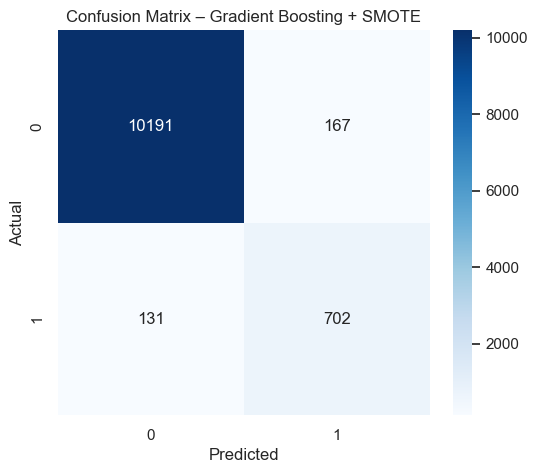

In [159]:
cm = confusion_matrix(y_test, y_pred_gb_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Gradient Boosting + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

***Confusion Matrix Interpretation – Gradient Boosting + SMOTE***

The confusion matrix provides a concrete breakdown of the final model’s decisions on the test set.

- **True Negatives (TN) = 10,191**: non-default loans correctly classified as non-default  
- **True Positives (TP) = 702**: defaulted loans correctly identified as default  
- **False Positives (FP) = 167**: non-default loans incorrectly flagged as default  
- **False Negatives (FN) = 131**: defaulted loans missed by the model  

This outcome reflects a strong default-detection capability:
the model captures most defaults (high sensitivity) while keeping the number of false alarms relatively low.
In credit-risk screening, reducing **false negatives** is particularly important because missed defaults typically carry higher cost than additional reviews caused by false positives.

## 18. ROC Curve (Final Model)

The ROC curve visualizes the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR)
across all possible classification thresholds for the selected final model.

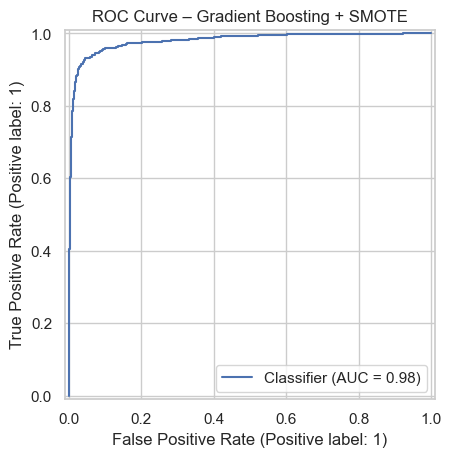

In [162]:
RocCurveDisplay.from_predictions(y_test, y_proba_gb_smote)
plt.title("ROC Curve – Gradient Boosting + SMOTE")
plt.show()

***ROC Curve Analysis – Gradient Boosting + SMOTE***

The ROC curve illustrates the trade-off between the True Positive Rate (TPR / recall) and the False Positive Rate (FPR) across all possible classification thresholds. The curve is strongly concentrated near the top-left corner, indicating that the model can achieve high sensitivity while keeping false positives relatively low.

The ROC-AUC is approximately **0.98**, which reflects excellent discriminative ability: the model ranks defaulted loans higher than non-defaulted loans with very high reliability. This suggests robust class separation across a wide range of thresholds rather than dependence on a single cutoff.

Overall, the ROC curve supports the suitability of the final model for credit-risk screening, enabling flexible threshold selection depending on whether the operational priority is minimizing missed defaults (false negatives) or limiting false alarms (false positives).

## 19. Feature Importance (Final Model)

To improve interpretability, feature importances are extracted from the final selected model (Gradient Boosting + SMOTE). For tree-based models, feature importance reflects how much each feature contributes to reducing impurity across the ensemble, providing a global view of which variables most strongly influence predictions.

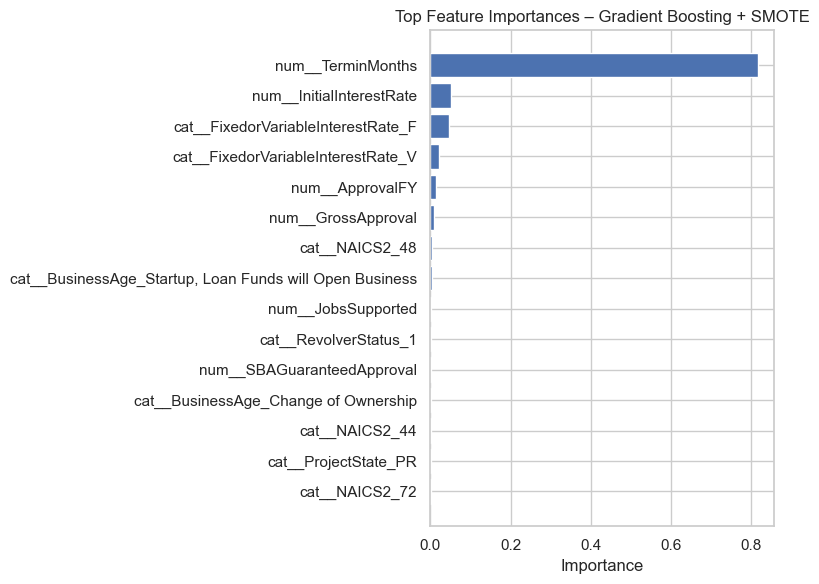

In [132]:
best_pipe = grid_gb_smote.best_estimator_

gb_model = best_pipe.named_steps["clf"]
preproc = best_pipe.named_steps["preprocessor"]

# Get feature names after preprocessing (including one-hot encoded categories)
feature_names = preproc.get_feature_names_out()

# Tree-based feature importances
importances = gb_model.feature_importances_

# Plot top N most important features
top_n = 15
idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[idx][::-1], importances[idx][::-1])
plt.title("Top Feature Importances – Gradient Boosting + SMOTE")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Feature Importance Analysis – Gradient Boosting + SMOTE

The feature importance results provide a global explanation of which variables most strongly drive the final model’s default-risk predictions.

The most influential feature by a large margin is **loan term length (`TerminMonths`)**, indicating that repayment horizon is the dominant risk driver in this dataset. Longer terms typically increase exposure to uncertainty in business performance and macroeconomic conditions, which can elevate default risk.

The **initial interest rate (`InitialInterestRate`)** is the second most important feature, consistent with risk-based pricing: higher rates are often assigned to riskier borrowers and therefore carry strong predictive signal. The model also assigns meaningful importance to **interest-rate type indicators** (fixed vs. variable), suggesting that contract structure contributes additional risk information beyond the rate level alone.

Temporal and exposure-related variables also appear among the top contributors, including **approval year (`ApprovalFY`)** and loan size measures such as **`GrossApproval`** and **`SBAGuaranteedApproval`**, which reflect the timing of origination and the magnitude of financial exposure.

Finally, several categorical indicators related to **industry sector (`NAICS2`)**, **business age**, **revolver status**, and **project state** appear with smaller importances. This pattern suggests that, in this portfolio, **loan structure, pricing, and term characteristics** are more informative for default prediction than sector/location attributes alone.

Overall, the importance profile is economically plausible and supports interpretability: the model’s predictions are primarily driven by meaningful lending terms and pricing features rather than arbitrary noise.

## 20. Unsupervised Learning: K-Means Clustering

To complement the supervised default-prediction models, K-Means clustering is applied to identify interpretable loan/borrower “profiles” without using the target label. The analysis is performed on a random sample of 20,000 loans to keep runtime reasonable.

Clustering is based on a small numeric feature set that captures core loan structure and exposure:
**GrossApproval, InitialInterestRate, TerminMonths, and JobsSupported**. All features are standardized prior to clustering to ensure that differences in scale do not dominate distance computations.

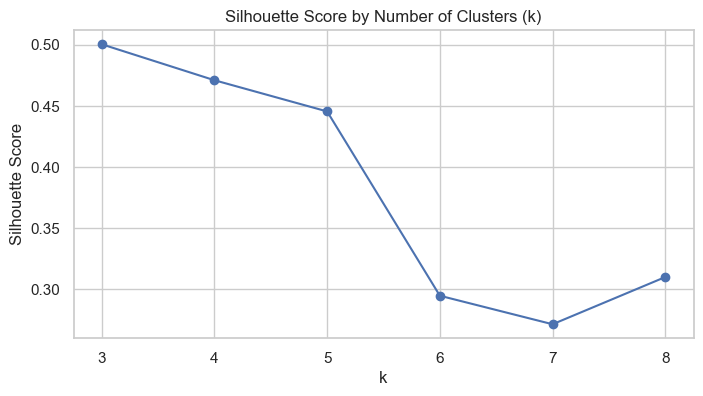

Selected k: 3


,count,avg_gross,avg_rate,avg_term,avg_jobs,default_rate
cluster,,,,,,
0,15782,219922.00,7.25,96.75,7.29,0.09
1,3535,1664412.25,5.66,274.20,11.49,0.01
2,683,1384243.92,6.15,129.82,88.94,0.02


In [138]:
cluster_features = ["GrossApproval", "InitialInterestRate", "TerminMonths", "JobsSupported"]

# Sample for computational efficiency
df_sample = df_model_clean.sample(n=20000, random_state=RANDOM_STATE)
X_cluster = df_sample[cluster_features].copy()

# Standardize features (required for distance-based clustering)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Choose k using silhouette score
candidate_ks = [3, 4, 5, 6, 7, 8]
silhouette_scores = []

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X_cluster_scaled)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(candidate_ks, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

k_opt = candidate_ks[int(np.argmax(silhouette_scores))]
print("Selected k:", k_opt)

# Fit final K-Means and attach cluster labels
kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init="auto")
df_sample["cluster"] = kmeans.fit_predict(X_cluster_scaled)

# Cluster summary table (default rate is reported for interpretation only)
cluster_profile = (
    df_sample.groupby("cluster")
    .agg(
        count=("LoanDefault", "size"),
        avg_gross=("GrossApproval", "mean"),
        avg_rate=("InitialInterestRate", "mean"),
        avg_term=("TerminMonths", "mean"),
        avg_jobs=("JobsSupported", "mean"),
        default_rate=("LoanDefault", "mean")
    )
    .round(2)
)

cluster_profile

#### Unsupervised Learning – K-Means Clustering Analysis

To explore structural patterns in the loan portfolio beyond supervised prediction, a K-Means clustering analysis was applied to a random sample of 20,000 loans using four standardized numeric features: **GrossApproval**, **InitialInterestRate**, **TerminMonths**, and **JobsSupported**. Standardization ensures that variables measured on different scales contribute comparably to the distance calculations.

##### Selection of the Number of Clusters (k)

The number of clusters was selected using the **Silhouette Score**, which evaluates how well-separated and internally cohesive the clusters are. The silhouette curve peaked at **k = 3**, indicating the most coherent and well-separated clustering among the tested values. Therefore, **three clusters** were selected for interpretation.

##### Cluster Profiles and Interpretation (k = 3)

The resulting clusters represent distinct loan profiles, and the observed default rate (reported post hoc for interpretation) varies meaningfully across segments:

- **Cluster 0 – Smaller, shorter-term loans with higher observed risk**  
  This is the largest cluster (**15,782 loans**) with a lower average approval amount (**$219,922**) and shorter average term (**96.75 months**). It shows the **highest default rate (~9%)**, suggesting this segment contains relatively higher-risk loans.

- **Cluster 1 – Large, long-term, lowest-risk loans**  
  This cluster (**3,535 loans**) is characterized by the **largest approval amounts** (**$1,664,412**) and the **longest terms** (**274.20 months**), along with the lowest average rate (**5.66%**). It has the **lowest default rate (~1%)**, consistent with a more stable or well-supported borrower/loan profile.

- **Cluster 2 – High jobs-supported / employment-impact loans**  
  Although the smallest cluster (**683 loans**), it stands out by an exceptionally high average **JobsSupported** (**88.94**). The default rate is **low (~2%)**, indicating relatively strong performance despite large approval amounts (**$1,384,244**) and moderate term length (**129.82 months**).

##### Summary

Overall, the clustering reveals meaningful portfolio segments that differ strongly in loan size, term structure, employment impact, and observed default risk. These unsupervised insights complement the supervised modeling results by providing an interpretable segmentation view that can support targeted risk monitoring and portfolio strategy.

## 21. Cluster Visualization

To visually validate the clustering structure, a boxplot is used to compare the distribution of **GrossApproval** across the three K-Means clusters. This plot highlights differences in central tendency, variability, and the presence of extreme values (outliers) for each segment.

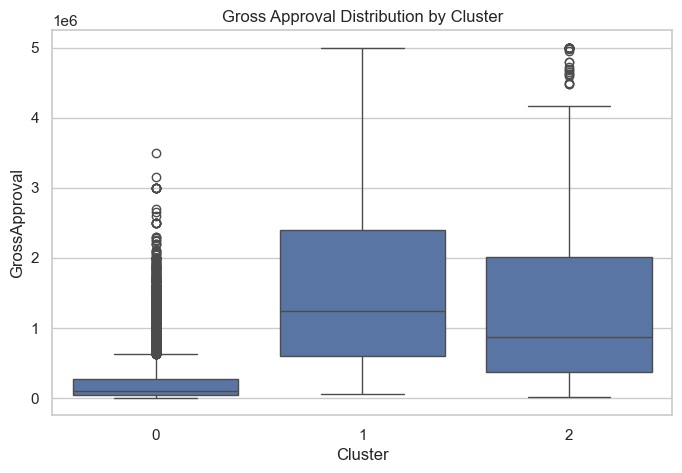

In [145]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_sample, x="cluster", y="GrossApproval")
plt.title("Gross Approval Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("GrossApproval")
plt.show()

#### Gross Approval Amount by Cluster – Distribution Analysis

The boxplot shows a clear separation in **GrossApproval** across the three K-Means clusters, confirming that loan size is a key dimension differentiating the discovered portfolio segments.

- **Cluster 0** is concentrated around substantially smaller approval amounts, with a low median and a relatively narrow interquartile range. Although a number of outliers exist (occasional large loans), the typical loan in this cluster is small, consistent with the “small-loan” segment identified in the cluster profiles.

- **Cluster 1** exhibits the highest approval amounts overall, with the largest median and the widest spread. The long upper whisker indicates the presence of very large approvals, reflecting a high-exposure segment with substantial variability in loan size.

- **Cluster 2** also contains large approvals but with a lower median than Cluster 1. Its distribution suggests a “medium-to-large” segment: approvals are generally much larger than Cluster 0, yet typically less extreme than Cluster 1.

##### Interpretation

Overall, the visualization reinforces the interpretation of the clusters as **distinct financial segments**. Importantly, the presence of large loans in Clusters 1 and 2—combined with their lower observed default rates in the profiling table—highlights that **loan size alone does not determine risk**. Instead, approval amount should be interpreted jointly with other drivers such as term length, pricing (interest rate), and business/employment characteristics.

## Conclusion

The **Gradient Boosting + SMOTE** model is selected as the final supervised approach because it provides a strong, risk-aware trade-off under class imbalance.
It achieves high minority-class detection (recall), maintains a strong balance between precision and recall (F1-score), and demonstrates excellent ranking performance (ROC-AUC and PR-AUC).
Applying SMOTE increases sensitivity to defaults while keeping overall accuracy high, which aligns with credit-risk screening objectives where missed defaults are costly.

Model interpretability further supports the predictive results: feature-importance analysis indicates that economically meaningful variables—most notably **loan term length** and **interest rate / interest-rate structure**—are primary drivers of default risk.
In addition, the clustering analysis reveals distinct loan segments with different financial profiles and observed default rates, providing a complementary portfolio-level view beyond individual predictions.

Overall, the combined supervised and unsupervised analyses deliver both robust predictive performance and actionable business insight for SBA 7(a) loan default risk assessment.